## Project Goal
The goal of this project is to predict median house prices in Boston neighborhoods using historical housing data. By leveraging machine learning regression models, we aim to develop an effective pricing system to assist real estate agents, home buyers, and urban planners in decision-making.

### 1 Data loading and preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
url = 'https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'
data = pd.read_csv(url)
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### 2 Exploratory Data Analysis
#### Visualising median house price

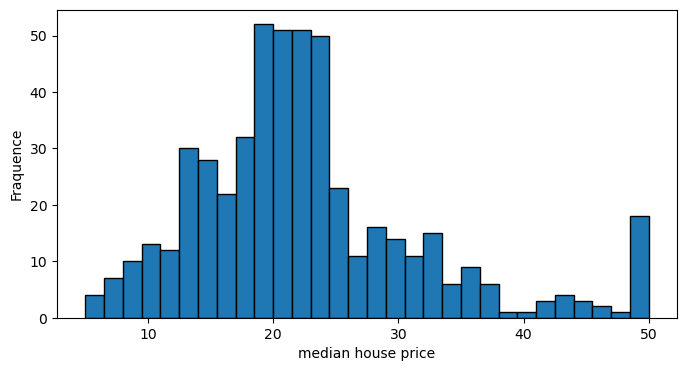

In [3]:
plt.figure(figsize=(8,4))
plt.hist(data['medv'], bins = 30, edgecolor='black')
plt.xlabel('median house price')
plt.ylabel('Fraquence')
plt.show()

#### Statistical Summary of All Variables (Boxplot)

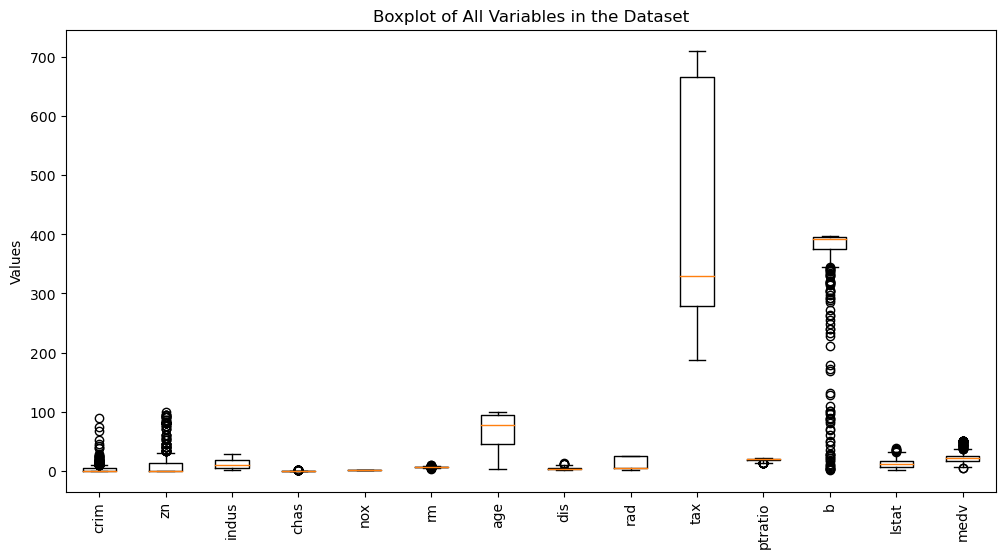

In [4]:
plt.figure(figsize=(12,6))
plt.boxplot(data.values, labels=data.columns)

plt.xticks(rotation=90)
plt.ylabel('Values')
plt.title('Boxplot of All Variables in the Dataset')
plt.show()

#### Correlation Matrix

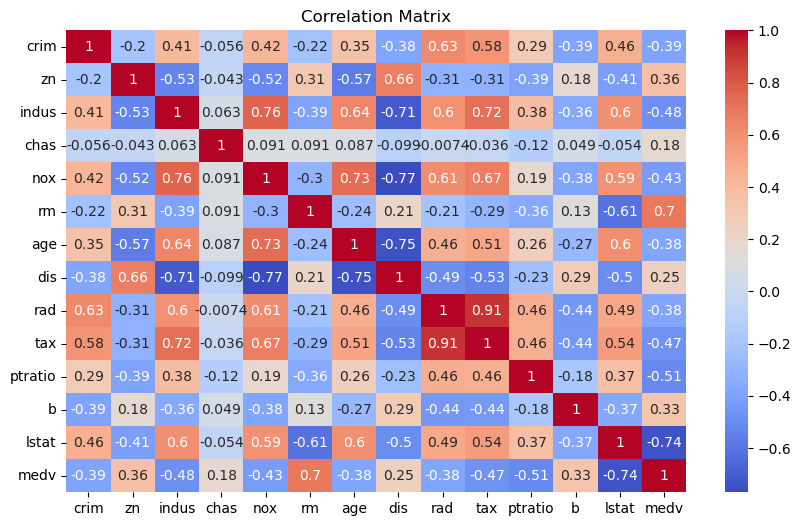

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

cor = data.corr()

plt.figure(figsize=(10,6))
sns.heatmap(cor, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

### 3 Machine learning for mediane house price prediction


Split the data int train and test set

In [7]:
# Let's split the data
X = data.drop('medv', axis=1)
y = data['medv']
Scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

Model for traning: Random Forest, Gradient Boosting and Decision Tree Regression

In [8]:
# Define models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

results = {}
predictions = {}

# Train models and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = r2_score(y_test, y_pred)
    predictions[name] = y_pred
    
    print(f'{name}: R² = {results[name]:.4f}')

# Find best model
best_model = max(results, key=results.get)
print(f"\nBest model: {best_model} with R² = {results[best_model]:.4f}")

Random Forest: R² = 0.8923
Gradient Boosting: R² = 0.9153
Decision Tree: R² = 0.8580

Best model: Gradient Boosting with R² = 0.9153


#### 4 Visualizing prediction

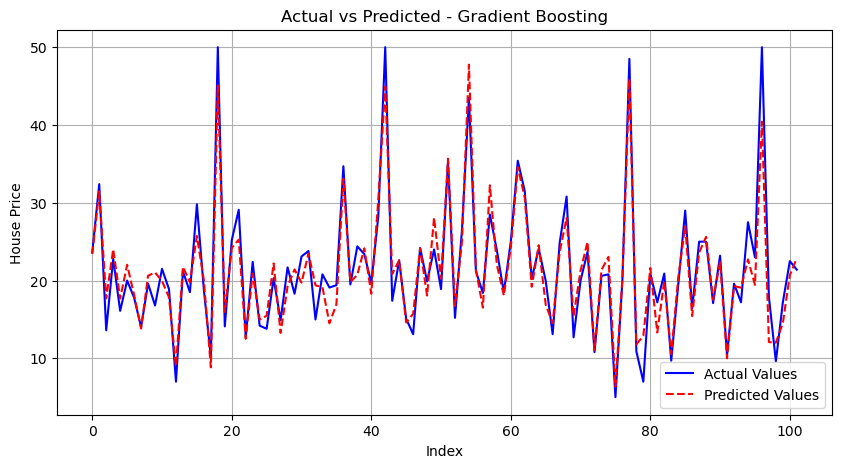

In [9]:
# Plot Actual vs Predicted for best model
plt.figure(figsize=(10,5))

# Actual values
plt.plot(y_test.values, label="Actual Values", color="blue")

# Predicted values
plt.plot(predictions[best_model], label="Predicted Values", color="red", linestyle="--")

plt.title(f"Actual vs Predicted - {best_model}")
plt.xlabel("Index")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)

plt.show()

## Conclusion

We successfully built a machine learning model to predict house prices using the Boston Housing dataset.

We compared several regression models, including Decision Tree, Random Forest, and Gradient Boosting. The Gradient Boosting model performed the best, achieving the highest R² score of 0.9153, indicating more accurate and reliable predictions compared to the other models.

Visualization of the results shows that the model is able to capture the general trends in housing prices effectively, although some prediction errors still exist, which is expected in real-world regression problems.

Overall, this project demonstrates that machine learning models, especially ensemble methods, can be effectively used for house price prediction tasks.